# A. VISAYAS COMMUNICATION DATAFRAME

In [17]:
import pandas as pd

In [65]:
board2 = pd.read_excel('board2.xlsx') #reads the xlsx excel file and saves as a variable with the name 'board2'
   
averages = board2[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1) #creates a new dataframe containing the averages of the chosen columns inside the bracket 
boardavg = pd.concat([board2, averages.rename('Average')], axis=1) #combines newly created dataframe of averages with board 2 to create an all in one dataframe to hold values.
boardavg

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


In [68]:
board3 =boardavg[(boardavg['Hometown'] == 'Visayas') #filters to only show rows categorized into visayas for the hometown column
     & 
     (boardavg['Track'] == 'Communication')] #specifies further that the chosen rows must also be categorized as communication in the track column
board3

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
10,S11,Female,Communication,Visayas,48,56,48,67,54.75
11,S12,Male,Communication,Visayas,89,67,84,64,76.00
17,S18,Male,Communication,Visayas,81,40,81,52,63.50
21,S22,Female,Communication,Visayas,64,39,89,58,62.50
27,S28,Male,Communication,Visayas,85,53,80,53,67.75


In [69]:
VisComm = board3.loc[:, ['Name', 'Gender', 'Math', 'Electronics', 'Average']] #only saves the chosen columns into 'VisComm' variable
VisComm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


In [70]:
print('Amount of rows:', VisComm.shape[0]) #show amount of rows in VisComm

Amount of rows: 5


In [ ]:
VisComm.to_csv('VisComm.csv') #saves VisComm dataframe as .csv excel file

# B. Visayas Female Dataframe

In [71]:
VisFemale =boardavg[(boardavg['Hometown'] == 'Visayas') 
     & 
     (boardavg['Gender'] == 'Female')].loc[:, ['Name', 'Track', 'GEAS', 'Electronics', 'Average']]
VisFemale

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [72]:
VisFemale[VisFemale['Average']>=60]

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


# C. Category-Average Visualization

## a.

In [116]:
boardavg.groupby('Track')['Average'].mean()

Track
Communication       67.975
Instrumentation     65.225
Microelectronics    67.500
Name: Average, dtype: float64

In [123]:
boardavg.groupby('Gender')['Average'].mean()

Gender
Female    66.616667
Male      67.183333
Name: Average, dtype: float64

In [114]:
boardavg.groupby('Hometown')['Average'].mean()

Hometown
Luzon       68.083333
Mindanao    66.678571
Visayas     65.750000
Name: Average, dtype: float64

## b. 

In [110]:
Trackavg = pd.DataFrame(data=
                        boardavg.groupby('Track')['Average'].mean())
Trackavg

,Average
Track,
Communication,67.975
Instrumentation,65.225
Microelectronics,67.500


In [111]:
Genderavg = pd.DataFrame(data=
                         boardavg.groupby('Gender')['Average'].mean())
Genderavg

,Average
Gender,
Female,66.616667
Male,67.183333


In [112]:
Hometownavg = pd.DataFrame(data=
                           boardavg.groupby('Hometown')['Average'].mean())
Hometownavg

,Average
Hometown,
Luzon,68.083333
Mindanao,66.678571
Visayas,65.750000


## c.

In [178]:
categories = pd.concat([Hometownavg, Genderavg, Trackavg], axis = 1)
categories.columns = ['Hometown averages', 'Gender averages', 'Track averages']

<Axes: title={'center': 'Mean Averages per category'}>

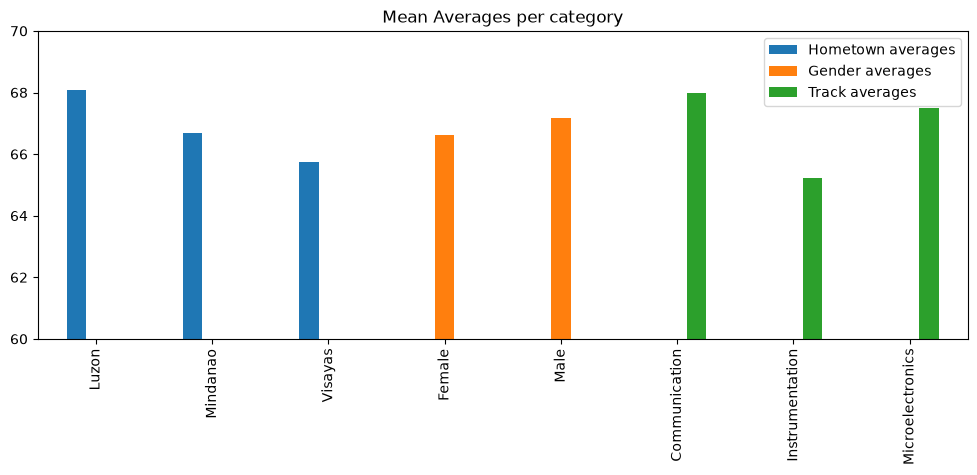

In [179]:
categories.plot(kind='bar', layout=(1, 3), figsize=(12, 4), ylim = (60, 70), title="Mean Averages per category")

## d.

<Axes: title={'center': 'Mean Averages per category'}>

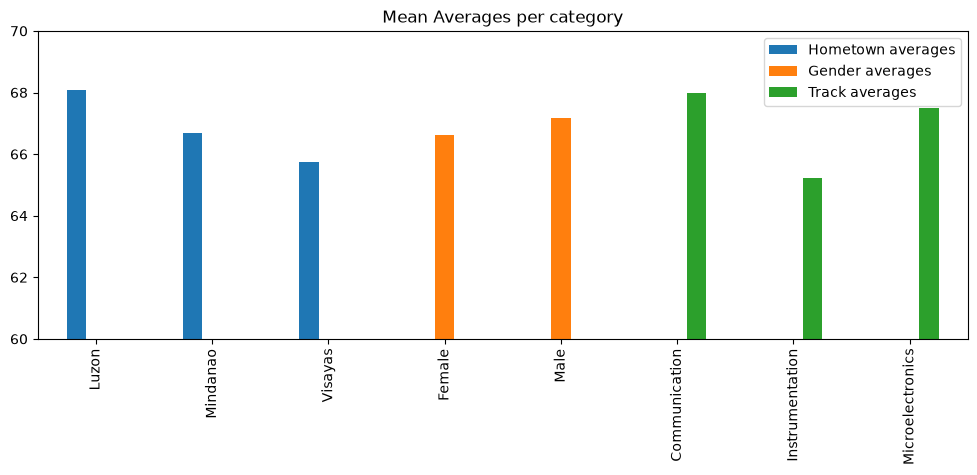

In [179]:
categories.plot(kind='bar', layout=(1, 3), figsize=(12, 4), ylim = (60, 70), title="Mean Averages per category")

### Hometown Averages: For the feature of hometown averages, the graph shows that Luzon has the highest mean among the three categories.
### Gender Averages: Between the two categories in the gender averages feature, the male category has a higher mean value for its averages.
### Track Averages: The communications category contains the highest mean value for its averages in the Track feature as compared to the other two categories. 